In [22]:
import sys
# ambiente no anaconda
print(sys.executable)

/home/fabiene/anaconda3/envs/udemy_serie_arima/bin/python


In [23]:
# no linux

# conda env list
# # conda environments:
# #
# base                  *  /home/fabiene/anaconda3
# Maq2                     /home/fabiene/anaconda3/envs/Maq2
# RBA_est                  /home/fabiene/anaconda3/envs/RBA_est
# Robyn                    /home/fabiene/anaconda3/envs/Robyn
# Udemy                    /home/fabiene/anaconda3/envs/Udemy
# YouTube                  /home/fabiene/anaconda3/envs/YouTube
# face-env                 /home/fabiene/anaconda3/envs/face-env
# orange3                  /home/fabiene/anaconda3/envs/orange3
# pycaret-env              /home/fabiene/anaconda3/envs/pycaret-env


#(base) fabiene@~$ conda create --name udemy_serie_arima
# conda activate udemy_serie_arima
# (udemy_serie_arima) fabiene@:~$ 




# Série temporal com Facebook Prophet - previsão de visualizações diárias de páginas web

Prophet => profeta

## Instalação da biblioteca e importação da base de dados

- Visualizações diárias de uma página web da Wikipedia: https://en.wikipedia.org/wiki/Peyton_Manning

Peyton Williams Manning (born March 24, 1976) is an American former professional football quarterback

In [24]:
import pandas as pd

dataset = pd.read_csv('page_wikipedia.csv')
dataset.tail(20)

,date,views
2885,2016-01-01,7.589336
2886,2016-01-02,7.825245
2887,2016-01-03,8.249314
2888,2016-01-04,9.295141
2889,2016-01-05,8.568266
2890,2016-01-06,8.352554
2891,2016-01-07,8.295798
2892,2016-01-08,8.290293
2893,2016-01-09,7.785721
2894,2016-01-10,8.281724


In [25]:
#!pip install fbprophet

# atualizado 
#!pip install prophet

In [26]:
#from fbprophet import Prophet


In [27]:
import prophet

In [28]:
# nove anos de dados completos
dataset_teste = dataset.copy()

In [29]:
dataset_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2905 entries, 0 to 2904
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2905 non-null   object 
 1   views   2905 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.5+ KB


In [30]:
dataset_teste['date'] = pd.to_datetime(dataset_teste['date'])

In [31]:
dataset_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2905 entries, 0 to 2904
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2905 non-null   datetime64[ns]
 1   views   2905 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 45.5 KB


In [32]:
# %m é o mês com dois dígitos, %Y é o ano com quatro dígitos
#dataset_teste['mes-ano'] = dataset_teste['date'].dt.strftime('%m-%Y')

In [33]:
dataset_teste['mes-ano'] = (
    dataset_teste['date'].dt.month.astype(str) + 
    '-' + 
    dataset_teste['date'].dt.year.astype(str)
)

In [34]:
dataset_teste['mes-ano'].unique()

array(['12-2007', '1-2008', '2-2008', '3-2008', '4-2008', '5-2008',
       '6-2008', '7-2008', '8-2008', '9-2008', '10-2008', '11-2008',
       '12-2008', '1-2009', '2-2009', '3-2009', '4-2009', '5-2009',
       '6-2009', '7-2009', '8-2009', '9-2009', '10-2009', '11-2009',
       '12-2009', '1-2010', '2-2010', '3-2010', '4-2010', '5-2010',
       '6-2010', '7-2010', '8-2010', '9-2010', '10-2010', '11-2010',
       '12-2010', '1-2011', '2-2011', '3-2011', '4-2011', '5-2011',
       '6-2011', '7-2011', '8-2011', '9-2011', '10-2011', '11-2011',
       '12-2011', '1-2012', '2-2012', '3-2012', '4-2012', '5-2012',
       '6-2012', '7-2012', '8-2012', '9-2012', '10-2012', '11-2012',
       '12-2012', '1-2013', '2-2013', '3-2013', '4-2013', '5-2013',
       '6-2013', '7-2013', '8-2013', '9-2013', '10-2013', '11-2013',
       '12-2013', '1-2014', '2-2014', '3-2014', '4-2014', '5-2014',
       '6-2014', '7-2014', '8-2014', '9-2014', '10-2014', '11-2014',
       '12-2014', '1-2015', '2-2015', '3-

In [35]:
dataset_teste['ano'] = (
    dataset_teste['date'].dt.year
)

In [36]:
dataset_teste['ano'].unique()

array([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016],
      dtype=int32)

In [37]:
len(dataset_teste['ano'].unique())

10

média, desvio padrão, primeiro quartil (25%), 50% mediana e 75% (terceiro quartil), valores máximos e mínimos

In [38]:
dataset.describe()

,views
count,2905.000000
mean,8.138958
std,0.845957
min,5.262690
25%,7.514800
50%,7.997999
75%,8.580168
max,12.846747


histograma 

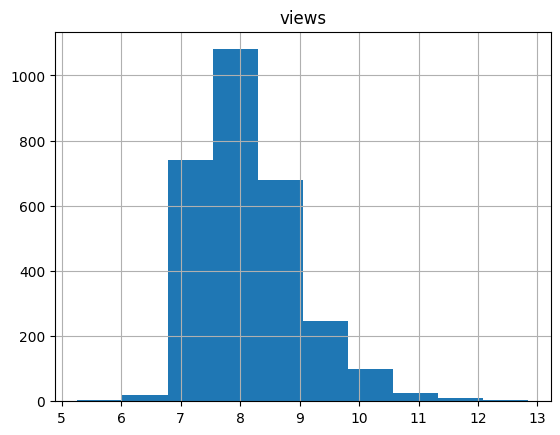

In [39]:
dataset.hist(); # maior frequência entre 7 e 8 visualizações

In [40]:
# padrão aceito para a biblioteca prophet ds data e dados de análise em y 
dataset = dataset[['date', 'views']].rename(columns = {'date': 'ds', 'views': 'y'})
dataset

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


In [41]:
# antes de rdar o programa temos que ordenar as datas
dataset = dataset.sort_values(by = 'ds')
dataset

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


# 31.3) Prophet Facebook

## Construção do modelo e previsões

In [43]:

from prophet import Prophet

# Agora o comando vai funcionar
model = Prophet()

In [44]:
model.fit(dataset)

18:47:34 - cmdstanpy - INFO - Chain [1] start processing
18:47:34 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
model.get_params()

AttributeError: 'Prophet' object has no attribute 'get_params'

In [47]:
# previsão para 90 dias em diante
future = model.make_future_dataframe(periods=90)


In [48]:
forecast = model.predict(future)

In [49]:
future

,ds
0,2007-12-10
1,2007-12-11
2,2007-12-12
3,2007-12-13
4,2007-12-14
...,...
2990,2016-04-15
2991,2016-04-16
2992,2016-04-17
2993,2016-04-18


In [52]:
#previsão
forecast.tail(20)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
2975,2016-03-31,7.488421,6.235517,7.456835,7.476017,7.509021,-0.643469,-0.643469,-0.643469,-0.072254,-0.072254,-0.072254,-0.571215,-0.571215,-0.571215,0.0,0.0,0.0,6.844952
2976,2016-04-01,7.487400,6.152983,7.411258,7.474624,7.508696,-0.667474,-0.667474,-0.667474,-0.069575,-0.069575,-0.069575,-0.597899,-0.597899,-0.597899,0.0,0.0,0.0,6.819925
2977,2016-04-02,7.486378,5.968867,7.223875,7.472658,7.508040,-0.932132,-0.932132,-0.932132,-0.311713,-0.311713,-0.311713,-0.620419,-0.620419,-0.620419,0.0,0.0,0.0,6.554246
2978,2016-04-03,7.485357,6.310038,7.528786,7.471325,7.507488,-0.590026,-0.590026,-0.590026,0.048287,0.048287,0.048287,-0.638313,-0.638313,-0.638313,0.0,0.0,0.0,6.895330
2979,2016-04-04,7.484335,6.588410,7.828338,7.469824,7.507085,-0.298951,-0.298951,-0.298951,0.352288,0.352288,0.352288,-0.651239,-0.651239,-0.651239,0.0,0.0,0.0,7.185384
2980,2016-04-05,7.483314,6.338459,7.570390,7.467893,7.507000,-0.539343,-0.539343,-0.539343,0.119636,0.119636,0.119636,-0.658979,-0.658979,-0.658979,0.0,0.0,0.0,6.943971
2981,2016-04-06,7.482292,6.148475,7.338836,7.466419,7.506352,-0.728112,-0.728112,-0.728112,-0.066669,-0.066669,-0.066669,-0.661443,-0.661443,-0.661443,0.0,0.0,0.0,6.754181
2982,2016-04-07,7.481271,6.115075,7.395466,7.464451,7.505670,-0.730928,-0.730928,-0.730928,-0.072254,-0.072254,-0.072254,-0.658674,-0.658674,-0.658674,0.0,0.0,0.0,6.750343
2983,2016-04-08,7.480249,6.145292,7.324160,7.463063,7.505153,-0.720416,-0.720416,-0.720416,-0.069575,-0.069575,-0.069575,-0.650841,-0.650841,-0.650841,0.0,0.0,0.0,6.759833
2984,2016-04-09,7.479228,5.939080,7.177090,7.461518,7.504302,-0.949949,-0.949949,-0.949949,-0.311713,-0.311713,-0.311713,-0.638236,-0.638236,-0.638236,0.0,0.0,0.0,6.529279


In [51]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2007-12-10,8.041708,8.213184,9.457622,8.041708,8.041708,0.802946,0.802946,0.802946,0.352288,0.352288,0.352288,0.450657,0.450657,0.450657,0.0,0.0,0.0,8.844654
1,2007-12-11,8.040161,7.966849,9.230078,8.040161,8.040161,0.553024,0.553024,0.553024,0.119636,0.119636,0.119636,0.433388,0.433388,0.433388,0.0,0.0,0.0,8.593185
2,2007-12-12,8.038615,7.787279,9.030399,8.038615,8.038615,0.350385,0.350385,0.350385,-0.066669,-0.066669,-0.066669,0.417054,0.417054,0.417054,0.0,0.0,0.0,8.389000
3,2007-12-13,8.037068,7.740781,8.938053,8.037068,8.037068,0.329846,0.329846,0.329846,-0.072254,-0.072254,-0.072254,0.402100,0.402100,0.402100,0.0,0.0,0.0,8.366914
4,2007-12-14,8.035522,7.683783,8.989869,8.035522,8.035522,0.319355,0.319355,0.319355,-0.069575,-0.069575,-0.069575,0.388931,0.388931,0.388931,0.0,0.0,0.0,8.354877


In [53]:
print(f"Modo de Sazonalidade: {model.seasonality_mode}")
print(f"Escala de Changepoints: {model.changepoint_prior_scale}")
print(f"Tipo de Crescimento: {model.growth}")

Modo de Sazonalidade: additive
Escala de Changepoints: 0.05
Tipo de Crescimento: linear


In [56]:
# configurações adicionais ou iniciais
# Mostra os parâmetros principais de configuração
params = {attr: getattr(model, attr) for attr in ['growth', 'changepoint_prior_scale', 'seasonality_mode', 'yearly_seasonality', 'weekly_seasonality', 'daily_seasonality']}
print(params)

{'growth': 'linear', 'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive', 'yearly_seasonality': 'auto', 'weekly_seasonality': 'auto', 'daily_seasonality': 'auto'}


In [57]:
print('tamanho dos dados inciais e previstos')
len(dataset), len(forecast)

tamanho dos dados inciais e previstos


(2905, 2995)

In [58]:
print('quantidades oficiais de previsão')
len(forecast) - len(dataset)

quantidades oficiais de previsão


90

# o forecast acaba apresentando todos os dados, mas necessitamos agora apenas os dados previstos 

In [59]:
forecast.tail(90)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
2905,2016-01-21,7.559924,7.950030,9.186620,7.559924,7.559924,0.999856,0.999856,0.999856,-0.072254,-0.072254,-0.072254,1.072110,1.072110,1.072110,0.0,0.0,0.0,8.559779
2906,2016-01-22,7.558902,7.934818,9.172827,7.558902,7.558902,1.016860,1.016860,1.016860,-0.069575,-0.069575,-0.069575,1.086435,1.086435,1.086435,0.0,0.0,0.0,8.575762
2907,2016-01-23,7.557881,7.707078,8.979881,7.557881,7.557881,0.786590,0.786590,0.786590,-0.311713,-0.311713,-0.311713,1.098303,1.098303,1.098303,0.0,0.0,0.0,8.344471
2908,2016-01-24,7.556859,8.164352,9.314172,7.556859,7.556859,1.155605,1.155605,1.155605,0.048287,0.048287,0.048287,1.107318,1.107318,1.107318,0.0,0.0,0.0,8.712464
2909,2016-01-25,7.555838,8.394487,9.607728,7.555838,7.555838,1.465357,1.465357,1.465357,0.352288,0.352288,0.352288,1.113068,1.113068,1.113068,0.0,0.0,0.0,9.021195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2990,2016-04-15,7.473099,6.243803,7.530610,7.451404,7.501784,-0.560879,-0.560879,-0.560879,-0.069575,-0.069575,-0.069575,-0.491304,-0.491304,-0.491304,0.0,0.0,0.0,6.912220
2991,2016-04-16,7.472077,6.104650,7.300248,7.449916,7.501262,-0.772928,-0.772928,-0.772928,-0.311713,-0.311713,-0.311713,-0.461215,-0.461215,-0.461215,0.0,0.0,0.0,6.699150
2992,2016-04-17,7.471056,6.475778,7.718458,7.448576,7.500969,-0.383238,-0.383238,-0.383238,0.048287,0.048287,0.048287,-0.431525,-0.431525,-0.431525,0.0,0.0,0.0,7.087818
2993,2016-04-18,7.470035,6.825517,8.005581,7.447236,7.500486,-0.050686,-0.050686,-0.050686,0.352288,0.352288,0.352288,-0.402974,-0.402974,-0.402974,0.0,0.0,0.0,7.419349


In [61]:
dataset['ds'].max() # máxima data real

'2016-01-20'

In [63]:
list(forecast.columns) # colunas de tendência, aditivos, semanal, anula, multiplos e suas variâncias

['ds',
 'trend',
 'yhat_lower',
 'yhat_upper',
 'trend_lower',
 'trend_upper',
 'additive_terms',
 'additive_terms_lower',
 'additive_terms_upper',
 'weekly',
 'weekly_lower',
 'weekly_upper',
 'yearly',
 'yearly_lower',
 'yearly_upper',
 'multiplicative_terms',
 'multiplicative_terms_lower',
 'multiplicative_terms_upper',
 'yhat']

### a previsão final fica no yhat